# Dataset 2: California Housing — Data Cleaning, Preprocessing & Feature Engineering

**Source:** California census-block housing data (the classic "California Housing Prices" dataset used
throughout Kaggle/Hands-On ML courses), mirrored on GitHub.

**Goal:** Predict `median_house_value` for a census block (regression). This notebook is
**numerically heavy** and complements the Titanic notebook by covering: numerical scaling methods in
depth, log transforms, outlier treatment, date/time feature engineering (on a synthetic transaction
date we add for teaching purposes), stratified *and* time-based splitting, and regression-specific
data-leakage traps.


In [1]:

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
np.random.seed(42)

RAW_PATH = "data/housing_raw.csv"
MESSY_PATH = "data/housing_messy.csv"
CLEAN_PATH = "data/housing_cleaned.csv"

df_raw = pd.read_csv(RAW_PATH)
print(df_raw.shape)
df_raw.head()


(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 1. Data Quality Assessment (on the original file)


In [2]:

print("dtypes:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isna().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("\nocean_proximity categories:", df_raw['ocean_proximity'].unique())
df_raw.describe().round(1)


dtypes:
 longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Missing values:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Duplicate rows: 0

ocean_proximity categories: <StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.0,20640.0,20640.0,20640.0,20433.0,20640.0,20640.0,20640.0,20640.0
mean,-119.6,35.6,28.6,2635.8,537.9,1425.5,499.5,3.9,206855.8
std,2.0,2.1,12.6,2181.6,421.4,1132.5,382.3,1.9,115395.6
min,-124.4,32.5,1.0,2.0,1.0,3.0,1.0,0.5,14999.0
25%,-121.8,33.9,18.0,1447.8,296.0,787.0,280.0,2.6,119600.0
50%,-118.5,34.3,29.0,2127.0,435.0,1166.0,409.0,3.5,179700.0
75%,-118.0,37.7,37.0,3148.0,647.0,1725.0,605.0,4.7,264725.0
max,-114.3,42.0,52.0,39320.0,6445.0,35682.0,6082.0,15.0,500001.0


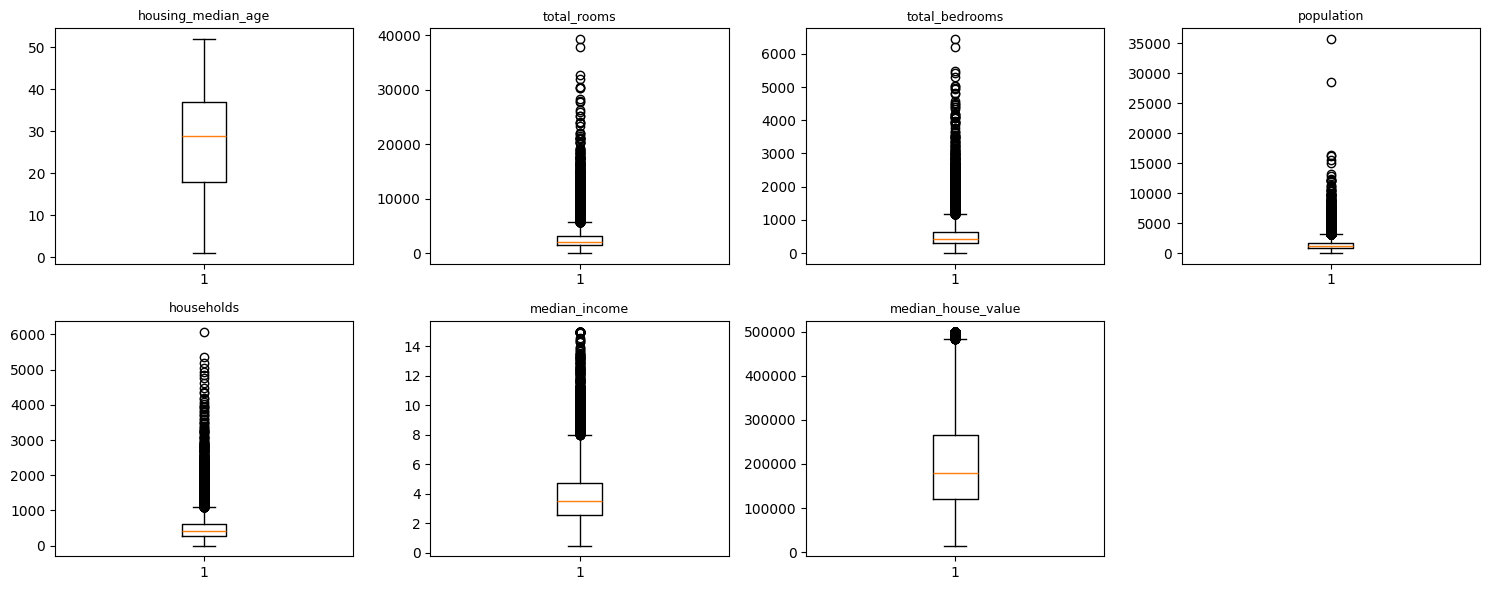

In [3]:

fig, axes = plt.subplots(2, 4, figsize=(15,6))
num_cols = ["housing_median_age","total_rooms","total_bedrooms","population",
            "households","median_income","median_house_value"]
for ax, col in zip(axes.ravel(), num_cols):
    ax.boxplot(df_raw[col].dropna())
    ax.set_title(col, fontsize=9)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig("figs/housing_boxplots_original.png", dpi=110)
plt.show()


The real file already has **missing values** in `total_bedrooms` (207 rows, ~1%) and clear
**outliers/skew** in several numeric columns (`total_rooms`, `population`, `median_house_value` is
capped at 500,001 — a data-capping artifact). No duplicates or bad categories. As with the Titanic
notebook, we deliberately corrupt a copy to practice the full checklist (Practical Task 1), and we
also attach a synthetic `sale_date` column so we have something to build **date/time features** from
— the original dataset is a single 1990-census snapshot with no dates at all.


## 2. Building a Deliberately Messy Version

- **Duplicate records** — repeat 150 random rows
- **Invalid values** — negative `housing_median_age`, `median_income` of 0
- **Inconsistent categories** — mixed casing/spacing in `ocean_proximity` (`'inland'`, `' INLAND'`)
- **Incorrect data types** — `total_rooms` and `households` stored as text with stray characters
- **Outliers** — extreme `population` spikes
- **Noisy data** — stray whitespace in the categorical column
- **Synthetic `sale_date`** — a plausible listing date per row, added purely so we can demonstrate
  date/time feature engineering and a time-based split later (clearly labeled as synthetic, not part
  of the original census data)


In [4]:

messy = df_raw.copy()
rng = np.random.RandomState(42)
n = len(messy)

# 1. Duplicate records
dup_rows = messy.sample(150, random_state=1)
messy = pd.concat([messy, dup_rows], ignore_index=True)
n = len(messy)

# 2. Invalid values
neg_idx = rng.choice(messy.index, 40, replace=False)
messy.loc[neg_idx, "housing_median_age"] = -messy.loc[neg_idx, "housing_median_age"]
zero_income_idx = rng.choice(messy.index, 25, replace=False)
messy.loc[zero_income_idx, "median_income"] = 0

# 3. Inconsistent categories
messy["ocean_proximity"] = messy["ocean_proximity"].astype(object)
mask = rng.rand(n) < 0.05
inland_mask = mask & (messy["ocean_proximity"] == "INLAND")
messy.loc[inland_mask, "ocean_proximity"] = rng.choice(["inland", " INLAND", "Inland "], inland_mask.sum())

# 4. Incorrect data types
messy["total_rooms"] = messy["total_rooms"].astype(object)
text_idx = rng.choice(messy.index, 30, replace=False)
messy.loc[text_idx, "total_rooms"] = messy.loc[text_idx, "total_rooms"].astype(str) + " rooms"
messy["households"] = messy["households"].astype(object)
space_idx = rng.choice(messy.index, 30, replace=False)
messy.loc[space_idx, "households"] = " " + messy.loc[space_idx, "households"].astype(str)

# 5. Outliers
outlier_idx = rng.choice(messy.index, 15, replace=False)
messy.loc[outlier_idx, "population"] = rng.uniform(20000, 35000, 15)

# 6. Noisy text
noisy_idx = rng.choice(messy.index, 40, replace=False)
messy.loc[noisy_idx, "ocean_proximity"] = "  " + messy.loc[noisy_idx, "ocean_proximity"].astype(str) + "  "

# 7. Synthetic sale_date (SYNTHETIC, added only for date-feature-engineering practice)
start = pd.Timestamp("2018-01-01")
end = pd.Timestamp("2021-12-31")
rand_days = rng.randint(0, (end-start).days, n)
messy["sale_date"] = [start + pd.Timedelta(days=int(d)) for d in rand_days]

messy.to_csv(MESSY_PATH, index=False)
print("Messy shape:", messy.shape)
messy.sample(8, random_state=3)


Messy shape: (20790, 11)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,sale_date
15528,-117.08,33.12,43.0,107.0,44.0,107.0,48.0,0.7054,137500.0,<1H OCEAN,2018-12-23
8259,-118.18,33.77,30.0,1418.0,439.0,720.0,417.0,2.6371,159400.0,NEAR OCEAN,2019-11-26
9241,-119.87,36.93,13.0,1429.0,209.0,702.0,205.0,4.3625,111800.0,INLAND,2020-02-24
2686,-115.53,32.97,35.0,1583.0,340.0,933.0,318.0,2.4063,70700.0,INLAND,2018-05-15
2731,-115.56,32.80,28.0,1672.0,416.0,1335.0,397.0,1.5987,59400.0,Inland,2020-11-26
11217,-117.93,33.80,34.0,3903.0,717.0,2054.0,716.0,4.2731,218000.0,<1H OCEAN,2021-01-22
19965,-119.08,36.22,28.0,1606.0,320.0,1158.0,317.0,3.0324,55600.0,INLAND,2018-07-08
10387,-117.65,33.60,13.0,2319.0,430.0,1004.0,380.0,5.1330,316100.0,<1H OCEAN,2020-03-10


In [5]:

# Re-audit
print("Duplicate rows:", messy.duplicated(subset=[c for c in messy.columns if c!='sale_date']).sum())
print("Negative age rows:", (pd.to_numeric(messy['housing_median_age'], errors='coerce') < 0).sum())
print("Zero income rows:", (pd.to_numeric(messy['median_income'], errors='coerce') == 0).sum())
print("ocean_proximity unique raw values:", messy['ocean_proximity'].nunique())
print("total_rooms dtype:", messy['total_rooms'].dtype)
print("households dtype:", messy['households'].dtype)


Duplicate rows: 139
Negative age rows: 40
Zero income rows: 25
ocean_proximity unique raw values: 13
total_rooms dtype: object
households dtype: object


## 3. Cleaning the Messy Dataset


In [6]:

clean = messy.copy()

# --- Fix incorrect data types ---
clean["total_rooms"] = pd.to_numeric(clean["total_rooms"].astype(str).str.replace(" rooms","",regex=False), errors="coerce")
clean["households"] = pd.to_numeric(clean["households"].astype(str).str.strip(), errors="coerce")
clean["sale_date"] = pd.to_datetime(clean["sale_date"])

# --- Remove duplicate records (ignore sale_date since duplicates were stamped with new random dates) ---
before = len(clean)
subset_cols = [c for c in clean.columns if c != "sale_date"]
clean = clean.drop_duplicates(subset=subset_cols)
print(f"Removed {before-len(clean)} duplicate rows")

# --- Fix inconsistent categories ---
clean["ocean_proximity"] = clean["ocean_proximity"].astype(str).str.strip().str.upper()
print("ocean_proximity after cleaning:", clean["ocean_proximity"].unique())

# --- Fix invalid values ---
clean.loc[clean["housing_median_age"] < 0, "housing_median_age"] = np.nan
clean.loc[clean["median_income"] <= 0, "median_income"] = np.nan

print("\nRemaining missing values:\n", clean.isna().sum())

# Row deletion: median_income is central to stratified splitting later, and only a handful of
# rows are affected, so we drop rows with an invalid (now NaN) income rather than impute it.
before = len(clean)
clean = clean.dropna(subset=["median_income"])
print(f"\nDropped {before-len(clean)} rows with invalid median_income")


Removed 143 duplicate rows
ocean_proximity after cleaning: <StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

Remaining missing values:
 longitude               0
latitude                0
housing_median_age     40
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income          25
median_house_value      0
ocean_proximity         0
sale_date               0
dtype: int64

Dropped 25 rows with invalid median_income


## 4. Outlier Detection & Treatment (IQR method)


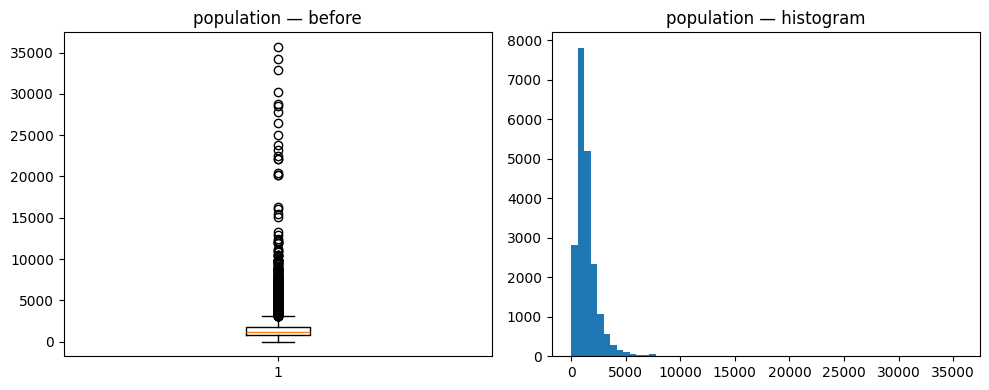

population IQR bounds: [-621, 3134] -> 1206 high outliers
median_house_value rows at the $500,001 census cap: 964 (4.7%) -- documented as a known data-collection artifact, left as-is.


In [7]:

def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].boxplot(clean["population"].dropna()); axes[0].set_title("population — before")
axes[1].hist(clean["population"].dropna(), bins=60); axes[1].set_title("population — histogram")
plt.tight_layout()
plt.savefig("figs/housing_population_before.png", dpi=110)
plt.show()

lo, hi = iqr_bounds(clean["population"])
print(f"population IQR bounds: [{lo:.0f}, {hi:.0f}] -> {(clean['population']>hi).sum()} high outliers")
clean["population"] = clean["population"].clip(lower=0, upper=hi)

# median_house_value is capped at 500001 in the source data (measurement artifact, not a fixable outlier)
capped = (clean["median_house_value"] >= 500001).sum()
print(f"median_house_value rows at the $500,001 census cap: {capped} "
      f"({capped/len(clean)*100:.1f}%) -- documented as a known data-collection artifact, left as-is.")


## 5. Missing-Value Treatment

`total_bedrooms` has genuine missingness (not injected); `housing_median_age` and `median_income`
have the invalid values we just nulled out. We compare strategies on `total_bedrooms`, which is
right-skewed and correlated with `total_rooms`/`households`.


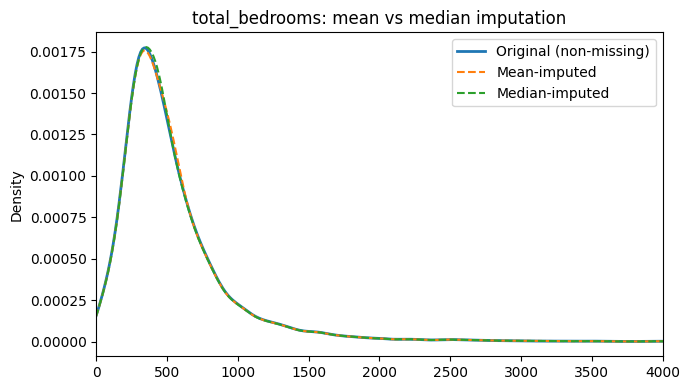

Mean: 537.9  Median: 435.0


In [8]:

tb_mean = clean["total_bedrooms"].fillna(clean["total_bedrooms"].mean())
tb_median = clean["total_bedrooms"].fillna(clean["total_bedrooms"].median())

fig, ax = plt.subplots(figsize=(7,4))
clean["total_bedrooms"].dropna().plot(kind="kde", ax=ax, label="Original (non-missing)", lw=2)
tb_mean.plot(kind="kde", ax=ax, label="Mean-imputed", ls="--")
tb_median.plot(kind="kde", ax=ax, label="Median-imputed", ls="--")
ax.set_xlim(0, 4000)
ax.set_title("total_bedrooms: mean vs median imputation")
ax.legend()
plt.tight_layout()
plt.savefig("figs/housing_imputation_compare.png", dpi=110)
plt.show()
print("Mean:", clean['total_bedrooms'].mean().round(1), " Median:", clean['total_bedrooms'].median())


In [9]:

from sklearn.impute import KNNImputer

# Advanced imputation: use correlated numeric columns
cols_for_knn = ["total_bedrooms","total_rooms","households","population"]
knn_imputer = KNNImputer(n_neighbors=5)
tb_knn = pd.DataFrame(knn_imputer.fit_transform(clean[cols_for_knn]), columns=cols_for_knn,
                       index=clean.index)["total_bedrooms"]
print("KNN-imputed total_bedrooms summary:\n", tb_knn.describe().round(1))
print("\nFor the final pipeline we use median imputation for numeric columns (simple, robust, reproducible)")
print("and mode imputation for the categorical column, exactly as in the Titanic notebook.")


KNN-imputed total_bedrooms summary:
 count    20622.0
mean       537.8
std        421.0
min          1.0
25%        296.0
50%        435.0
75%        647.0
max       6445.0
Name: total_bedrooms, dtype: float64

For the final pipeline we use median imputation for numeric columns (simple, robust, reproducible)
and mode imputation for the categorical column, exactly as in the Titanic notebook.


## 6. Feature Engineering

### Ratio / derived features (the classic California-housing engineered features)


In [10]:

clean["rooms_per_household"] = clean["total_rooms"] / clean["households"]
clean["bedrooms_per_room"] = clean["total_bedrooms"] / clean["total_rooms"]
clean["population_per_household"] = clean["population"] / clean["households"]

print(clean[["rooms_per_household","bedrooms_per_room","population_per_household"]].describe().round(2))


       rooms_per_household  bedrooms_per_room  population_per_household
count             20622.00           20416.00                  20622.00
mean                  5.43               0.21                      2.96
std                   2.47               0.06                      5.21
min                   0.85               0.10                      0.52
25%                   4.44               0.18                      2.39
50%                   5.23               0.20                      2.78
75%                   6.05               0.24                      3.25
max                 141.91               1.00                    522.35


### Date/time features (from the synthetic `sale_date` column)


In [11]:

clean["sale_year"] = clean["sale_date"].dt.year
clean["sale_month"] = clean["sale_date"].dt.month
clean["sale_quarter"] = clean["sale_date"].dt.quarter
clean["sale_dayofweek"] = clean["sale_date"].dt.dayofweek
clean["is_weekend_sale"] = clean["sale_dayofweek"].isin([5,6]).astype(int)
reference_date = clean["sale_date"].max()
clean["days_since_sale"] = (reference_date - clean["sale_date"]).dt.days

print(clean[["sale_date","sale_year","sale_month","sale_quarter","sale_dayofweek",
             "is_weekend_sale","days_since_sale"]].head())


   sale_date  sale_year  sale_month  sale_quarter  sale_dayofweek  \
0 2018-03-06       2018           3             1               1   
1 2021-03-19       2021           3             1               4   
2 2018-01-08       2018           1             1               0   
3 2019-05-16       2019           5             2               3   
4 2019-10-19       2019          10             4               5   

   is_weekend_sale  days_since_sale  
0                0             1395  
1                0              286  
2                0             1452  
3                0              959  
4                1              803  


### Binning, text-length-style feature, interaction feature, domain feature


In [12]:

# Binning median_income into categories (also used for stratified splitting below)
clean["income_cat"] = pd.cut(clean["median_income"],
                              bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
                              labels=[1,2,3,4,5])

# "text-length"-style feature: length of the ocean_proximity category label (illustrative)
clean["ocean_proximity_label_len"] = clean["ocean_proximity"].str.len()

# Interaction feature: income x rooms_per_household (affluence combined with home size)
clean["income_x_rooms"] = clean["median_income"] * clean["rooms_per_household"]

# Domain-based feature: is this a coastal block?
clean["is_coastal"] = clean["ocean_proximity"].isin(["NEAR BAY","NEAR OCEAN","ISLAND","<1H OCEAN"]).astype(int)

clean[["income_cat","ocean_proximity_label_len","income_x_rooms","is_coastal"]].head()


,income_cat,ocean_proximity_label_len,income_x_rooms,is_coastal
0,5,8,58.144254,1
1,5,8,51.785271,1
2,5,8,60.150315,1
3,4,8,32.827897,1
4,3,8,24.161264,1


## 7. Numerical Feature Scaling & Log Transform

`total_rooms` and `population` are strongly right-skewed (a few very large census blocks), which is
exactly when a **log transform** helps before scaling.


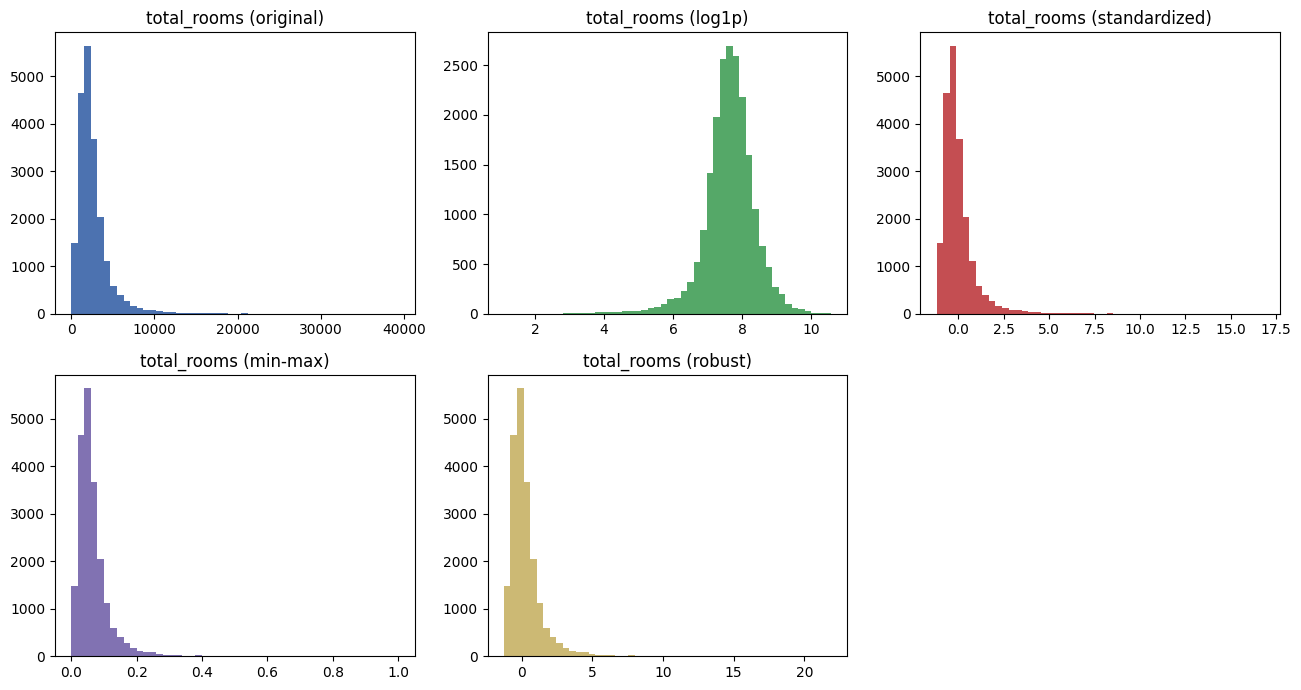

Skew - original: 4.15  log1p: -1.08
-> Standardization/min-max still leave the long right tail; log1p first, THEN scale, is the
   right order for a linear model. Robust scaling alone helps but doesn't fix skew, only outlier influence.


In [13]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

rooms = clean[["total_rooms"]].fillna(clean["total_rooms"].median())
rooms_log = np.log1p(rooms)

std_s = StandardScaler().fit_transform(rooms)
mm_s = MinMaxScaler().fit_transform(rooms)
rb_s = RobustScaler().fit_transform(rooms)

fig, axes = plt.subplots(2,3, figsize=(13,7))
axes[0,0].hist(rooms, bins=50, color="#4C72B0"); axes[0,0].set_title("total_rooms (original)")
axes[0,1].hist(rooms_log, bins=50, color="#55A868"); axes[0,1].set_title("total_rooms (log1p)")
axes[0,2].hist(std_s, bins=50, color="#C44E52"); axes[0,2].set_title("total_rooms (standardized)")
axes[1,0].hist(mm_s, bins=50, color="#8172B2"); axes[1,0].set_title("total_rooms (min-max)")
axes[1,1].hist(rb_s, bins=50, color="#CCB974"); axes[1,1].set_title("total_rooms (robust)")
axes[1,2].axis("off")
plt.tight_layout()
plt.savefig("figs/housing_scaling_compare.png", dpi=110)
plt.show()

print("Skew - original:", rooms['total_rooms'].skew().round(2), " log1p:", rooms_log['total_rooms'].skew().round(2))
print("-> Standardization/min-max still leave the long right tail; log1p first, THEN scale, is the")
print("   right order for a linear model. Robust scaling alone helps but doesn't fix skew, only outlier influence.")


## 8. Data Splitting

Two splitting strategies, both legitimate for different reasons:

1. **Stratified split on `income_cat`** — `median_income` is the single strongest predictor of
   `median_house_value`; a plain random split can under/over-represent high-income blocks in
   train vs. test purely by chance. This is the standard approach for this dataset (same idea as
   stratifying Titanic on `Survived`).
2. **Time-based split on the synthetic `sale_date`** — if this were genuinely transactional data
   arriving over time, a random split would let the model "see the future" (later sales) during
   training and get evaluated on earlier ones, which does not reflect real deployment. The correct
   approach is to train on earlier dates and test on later ones.


In [14]:

from sklearn.model_selection import train_test_split

feature_cols = ["longitude","latitude","housing_median_age","total_rooms","total_bedrooms",
                 "population","households","median_income","ocean_proximity",
                 "rooms_per_household","bedrooms_per_room","population_per_household",
                 "is_coastal","sale_month","sale_quarter","is_weekend_sale"]
X = clean[feature_cols].copy()
y = clean["median_house_value"]

# --- 1. Stratified split (by income category) ---
X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
    X, y, clean["income_cat"], test_size=0.30, stratify=clean["income_cat"], random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=strat_temp, random_state=42)

print("Stratified split sizes -> train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)
print("income_cat proportions (full data):\n", clean['income_cat'].value_counts(normalize=True).sort_index().round(3))
print("income_cat proportions (train):\n", strat_train.value_counts(normalize=True).sort_index().round(3))

# --- 2. Time-based split (by sale_date) ---
ordered = clean.sort_values("sale_date")
cut = int(len(ordered) * 0.8)
time_train = ordered.iloc[:cut]
time_test = ordered.iloc[cut:]
print(f"\nTime-based split -> train dates up to {time_train['sale_date'].max().date()}, "
      f"test dates from {time_test['sale_date'].min().date()} onward")
print("Train size:", len(time_train), " Test size:", len(time_test))


Stratified split sizes -> train: (14435, 16)  val: (3093, 16)  test: (3094, 16)
income_cat proportions (full data):
 income_cat
1    0.040
2    0.319
3    0.350
4    0.176
5    0.114
Name: proportion, dtype: float64
income_cat proportions (train):
 income_cat
1    0.040
2    0.319
3    0.350
4    0.176
5    0.114
Name: proportion, dtype: float64

Time-based split -> train dates up to 2021-03-11, test dates from 2021-03-11 onward
Train size: 16497  Test size: 4125


## 9. Data Leakage — Regression-Specific Traps

1. **Preprocessing before splitting** — scaling `median_income` (or imputing `total_bedrooms`) on
   the full dataset before splitting leaks test-set statistics into training, exactly as in the
   Titanic example.
2. **Target leakage** — `income_x_rooms` and `bedrooms_per_room` are engineered from *input*
   columns only, so they're safe. A genuine leak would be something like deriving a feature from
   `median_house_value` itself (e.g. "price per room" computed with the target) and feeding it back
   in as a predictor.
3. **Training–test contamination** — nearby census blocks have correlated `median_house_value`
   (spatial autocorrelation via `latitude`/`longitude`); a random split can place near-duplicate
   neighboring blocks on both sides, inflating test performance. A spatial or grouped split would be
   more honest for this dataset.
4. **Leakage through future information** — using the **random** split instead of the **time-based**
   split for the synthetic `sale_date` data would let the model implicitly learn from listings that
   happened after the test-set listings, which cannot happen in real deployment.


In [15]:

# Demonstrate #1 concretely: imputer fit on full data vs train-only
from sklearn.impute import SimpleImputer

imputer_wrong = SimpleImputer(strategy="median").fit(clean[["total_bedrooms"]])          # sees all rows
imputer_right = SimpleImputer(strategy="median").fit(X_train[["total_bedrooms"]])        # sees train only

print("Median learned from FULL data :", imputer_wrong.statistics_[0])
print("Median learned from TRAIN only:", imputer_right.statistics_[0])
print("-> Different values: the 'wrong' imputer already incorporated validation/test rows.")

# Demonstrate #4: compare stratified-random vs time-based split overlap in dates
print("\nIn the stratified-random split, train/test sale_dates overlap freely (dates aren't respected):")
print("  train date range:", X_train.index.map(lambda i: clean.loc[i,'sale_date']).min(), "to",
      X_train.index.map(lambda i: clean.loc[i,'sale_date']).max())
print("  test  date range:", X_test.index.map(lambda i: clean.loc[i,'sale_date']).min(), "to",
      X_test.index.map(lambda i: clean.loc[i,'sale_date']).max())
print("This overlap is fine here because sale_date is synthetic/unrelated to the target, but it")
print("would be a real leak if the data were genuinely time-ordered -- use the time-based split instead.")


Median learned from FULL data : 435.0
Median learned from TRAIN only: 436.0
-> Different values: the 'wrong' imputer already incorporated validation/test rows.

In the stratified-random split, train/test sale_dates overlap freely (dates aren't respected):


  train date range: 2018-01-01 00:00:00 to 2021-12-30 00:00:00
  test  date range: 2018-01-02 00:00:00 to 2021-12-30 00:00:00
This overlap is fine here because sale_date is synthetic/unrelated to the target, but it
would be a real leak if the data were genuinely time-ordered -- use the time-based split instead.


## 10. Reusable scikit-learn `Pipeline` + `ColumnTransformer`


In [16]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

skewed_features = ["total_rooms","total_bedrooms","population","households"]
other_numeric = ["longitude","latitude","housing_median_age","median_income",
                  "rooms_per_household","bedrooms_per_room","population_per_household"]
categorical_features = ["ocean_proximity"]
passthrough_features = ["is_coastal","sale_month","sale_quarter","is_weekend_sale"]

skewed_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("skewed", skewed_pipeline, skewed_features),
    ("num", numeric_pipeline, other_numeric),
    ("cat", categorical_pipeline, categorical_features),
    ("pass", "passthrough", passthrough_features),
])

full_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression()),
])

full_pipeline.fit(X_train, y_train)   # fit ONLY on training data
val_pred = full_pipeline.predict(X_val)
test_pred = full_pipeline.predict(X_test)

print("Validation MAE: $%.0f   R2: %.3f" % (mean_absolute_error(y_val, val_pred), r2_score(y_val, val_pred)))
print("Test MAE:       $%.0f   R2: %.3f" % (mean_absolute_error(y_test, test_pred), r2_score(y_test, test_pred)))


Validation MAE: $48478   R2: 0.661
Test MAE:       $48918   R2: 0.658


In [17]:

# Compare imputation strategies end-to-end (Practical Task 3)
results = {}
for strategy in ["mean", "median"]:
    sk_pipe = Pipeline([("imputer", SimpleImputer(strategy=strategy)),
                         ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                         ("scaler", StandardScaler())])
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy=strategy)), ("scaler", StandardScaler())])
    pre = ColumnTransformer([("skewed", sk_pipe, skewed_features),
                              ("num", num_pipe, other_numeric),
                              ("cat", categorical_pipeline, categorical_features),
                              ("pass", "passthrough", passthrough_features)])
    pipe = Pipeline([("preprocess", pre), ("model", LinearRegression())])
    pipe.fit(X_train, y_train)
    results[strategy] = r2_score(y_val, pipe.predict(X_val))

print("Validation R2 by numeric imputation strategy:")
for k,v in results.items():
    print(f"  {k:10s}: {v:.4f}")


Validation R2 by numeric imputation strategy:
  mean      : 0.6612
  median    : 0.6612


In [18]:

import joblib
joblib.dump(full_pipeline, "pipelines/housing_pipeline.joblib")

clean.to_csv(CLEAN_PATH, index=False)
print("Saved cleaned dataset ->", CLEAN_PATH)
print("Saved fitted pipeline ->", "pipelines/housing_pipeline.joblib")


Saved cleaned dataset -> data/housing_cleaned.csv
Saved fitted pipeline -> pipelines/housing_pipeline.joblib


## 11. Summary

- Started from the real California Housing census data, audited it, then deliberately reproduced
  every data-quality problem on a copy (`housing_messy.csv`), including adding a synthetic
  `sale_date` purely to practice date-feature engineering and time-based splitting.
- Cleaned dtypes, duplicates, inconsistent categories, invalid values, and capped `population` outliers.
- Compared mean/median imputation and KNN imputation for `total_bedrooms`.
- Engineered ratio features (`rooms_per_household`, `bedrooms_per_room`, `population_per_household`),
  date/time features (year/month/quarter/day-of-week/weekend/days-since), an income binning, an
  interaction feature, and a domain-based coastal flag.
- Compared standardization, min-max, robust scaling, and log1p transforms on skewed numeric columns.
- Built both a **stratified** split (by income category) and a **time-based** split (by sale date),
  and showed why each matters.
- Walked through 4 concrete regression-specific data-leakage traps.
- Wrapped everything in a `ColumnTransformer` + `Pipeline`, fit only on training data, and saved it.
